In [1]:
!pip install -U timm
!pip install -U albumentations

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.3/53.3 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 16.2 MB/s eta 0:00:00
  Attempting uninstall: timm
    Found existing installation: timm 1.0.12
    Uninstalling timm-1.0.12:
      Successfully uninstalled timm-1.0.12
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.0/66.0 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 273.9/273.9 kB 11.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 632.7/632.7 kB 24.8 MB/s eta 0:00:00
  Attempting uninstall: albucore
    Found existing installation: albucore 0.0.19
    Uninstalling albucore-0.0.19:
      Successfully uninstalled albucore-0.0.19
  Attempting uninstall: albumentations
    Found existing installation: albumentations 1.4.20
    Uninstalling albumentations-1.4.20:
      Successfully uninstalled albumentations-1.4.20


In [2]:
import torch
import torch.nn as nn
import albumentations as alb
from albumentations.pytorch import ToTensorV2
import timm
import cv2
from torch.utils.data import DataLoader
from torch.utils.data import Dataset
import pandas as pd
from collections import Counter

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [3]:
print(torch.__version__)
!python3 --version

2.5.1+cu121
Python 3.10.12


In [4]:
class ImageCaptioner(nn.Module):
  def __init__(self, context_length, vocabulary_size, num_blocks, model_dim, num_heads, prob):
    super().__init__()
    self.cnn_encoder = timm.create_model('efficientnet_b0', pretrained=True)

    # find size of in_features
    test_image = torch.zeros(1,3,224,224)
    with torch.no_grad():
      cnn_output = self.cnn_encoder(test_image)

    in_features = cnn_output.shape[1] # first is batch size
    self.project = nn.Linear(in_features, model_dim)

    self.word_embeddings = nn.Embedding(vocabulary_size, model_dim)
    self.pos_embeddings = nn.Embedding(context_length, model_dim)

    block = nn.TransformerDecoderLayer(model_dim, num_heads, 2*model_dim, dropout=prob, batch_first=True, norm_first=True)
    self.blocks = nn.TransformerDecoder(block, num_blocks)

    self.vocab_projection = nn.Linear(model_dim, vocabulary_size)

  def forward(self, images, true_labels):
    tokens_embedded = self.word_embeddings(true_labels)
    B, T = true_labels.shape
    positions = torch.arange(T).to(device)
    pos_embedded = self.pos_embeddings(positions)
    total_embeddings = tokens_embedded + pos_embedded

    with torch.no_grad():
      encoded_image = self.project(self.cnn_encoder(images).view(B, -1)) # B, C

    img_for_attention = torch.unsqueeze(encoded_image, dim=1) # B, 1, C

    # B, T, C
    attention_mask = nn.Transformer.generate_square_subsequent_mask(T).to(device)
    block_output = self.blocks(total_embeddings, img_for_attention, tgt_mask=attention_mask)

    vocabulary_vector = self.vocab_projection(block_output) # B, T, V

    return vocabulary_vector



In [5]:
# prepare dataset: Flickr8K dataset

from google.colab import drive
from google.colab.patches import cv2_imshow

drive.mount('/content/drive')
%cd "drive/MyDrive/Flickr8k"

caption_filename = 'captions.txt'
missing = '2258277193_586949ec62.jpg'

# Image, caption

with open(caption_filename) as captions:
  lines = captions.readlines()

get_captions = {}
all_captions = []

for caption in lines[1:]:
  data = caption.rstrip('\n').split('.jpg,')
  img_name = data[0] + '.jpg'
  if img_name == missing: # missing pic from dataset
    continue

  caption_list = get_captions.get(img_name, [])
  caption_list.append(data[1])

  get_captions[img_name] = caption_list
  all_captions.append(data[1])

Mounted at /content/drive
/content/drive/MyDrive/Flickr8k


In [6]:
!pip install nltk

In [28]:
from collections import Counter
import nltk

df = pd.DataFrame(columns=['filename', 'caption'])
df['filename'] = get_captions.keys()
df['caption'] = df['filename'].map(lambda filename : get_captions[filename])


nltk.download('punkt')
nltk.download('punkt_tab')
word_tokenizer = nltk.word_tokenize

vocab_frequency = Counter()
for caption in all_captions:
    vocab_frequency.update(word_tokenizer(caption.lower()))

vocabulary = ['<UNKNOWN>', '<PAD>', '<START>', '<END>'] + [word for word, freq in vocab_frequency.items()]
vocabulary_mapping = {word: idx for idx, word in enumerate(vocabulary)}
# print(vocabulary_mapping)
context_length = 20
V = len(vocabulary_mapping.keys())

class ImageCaptioningDataset(Dataset):
  def __init__(self, split):
    self.df = df
    self.img_size = 224
    transformation_list = [alb.Resize(self.img_size, self.img_size)]
    if split == "training":
      transformation_list.append(alb.HorizontalFlip())
      transformation_list.append(alb.ColorJitter())
    transformation_list.append(alb.Normalize())
    transformation_list.append(ToTensorV2())

    self.transformations = alb.Compose(transformation_list)

  def __len__(self):
    return len(self.df)

  def __getitem__(self, index):
    image_filename, captions = self.df.iloc[index]
    actual_image = cv2.cvtColor(cv2.imread('Images/' + image_filename), cv2.COLOR_BGR2RGB)
    cv2_imshow(actual_image)
    transformed_img = self.transformations(image=actual_image)['image']

    encoded_captions = []
    for i, c in enumerate(captions):
      split = word_tokenizer(c)

      integers = [vocabulary_mapping.get(word, 0) for word in split]
      integers = [2] + integers + [3] # start and end token

      if len(integers) <= context_length:
        pads_to_add = context_length - len(integers)
        integers += [1] * pads_to_add
      else:
        integers = integers[:context_length - 1] + [3]

      encoded_captions.append(torch.tensor(integers, dtype=torch.long))

    # 5 captions per image
    random_idx = torch.randint(0,5, (1,)).item()
    return transformed_img, encoded_captions[random_idx]

training_dataset = ImageCaptioningDataset('training')
training_data = DataLoader(training_dataset, batch_size=32, shuffle=True)


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [13]:
context_length = 20
vocabulary_size = len(vocabulary)
num_blocks = 6
model_dim = 512
num_heads = 16 # head_size = 512 / 16
prob = 0.5

model = ImageCaptioner(context_length, vocabulary_size, num_blocks, model_dim, num_heads, prob).to(device)

for layer in model.cnn_encoder.parameters():
  layer.requires_grad = False

loss_fn = nn.CrossEntropyLoss(ignore_index=vocabulary_mapping['<PAD>'])
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-5)


In [14]:
num_epochs = 20
iterations = 0

for epoch in range(num_epochs):
  for images, captions in training_data:
    images, captions = images.to(device), captions.to(device)
    B, T = captions.shape
    # B, 3, 224, 224
    # B, T -> captions
    model_prediction = model(images, captions) # B, T, V
    model_prediction = model_prediction.view(B*T, V)
    loss = loss_fn(model_prediction, captions.view(B*T))
    optimizer.zero_grad() # fix
    loss.backward()
    nn.utils.clip_grad_norm(model.parameters(), 2.0) # prevent exploding gradients
    optimizer.step()
    if iterations % 100 == 0:
      print(f"Loss: {loss.item()}")
    iterations += 1

<ipython-input-14-c1cb20a333d7>:14: FutureWarning: `torch.nn.utils.clip_grad_norm` is now deprecated in favor of `torch.nn.utils.clip_grad_norm_`.
  nn.utils.clip_grad_norm(model.parameters(), 2.0) # prevent exploding gradients


Loss: 10.797521591186523
Loss: 5.297994136810303
Loss: 4.291739463806152
Loss: 3.387326240539551
Loss: 3.1613450050354004
Loss: 2.790937662124634
Loss: 2.1898252964019775
Loss: 2.269681453704834
Loss: 2.24887752532959
Loss: 1.6765609979629517
Loss: 1.6986401081085205
Loss: 1.550708532333374
Loss: 1.4424270391464233
Loss: 1.3407844305038452
Loss: 1.297351598739624
Loss: 1.3025052547454834
Loss: 1.1174768209457397
Loss: 1.001018762588501
Loss: 1.0938103199005127
Loss: 1.1972163915634155
Loss: 0.7647889256477356
Loss: 0.8177847862243652
Loss: 0.9479109048843384
Loss: 0.7273423075675964
Loss: 0.8654994964599609
Loss: 0.7474080324172974
Loss: 0.5554362535476685
Loss: 0.7192929983139038
Loss: 0.6864506602287292
Loss: 0.5348131656646729
Loss: 0.485582172870636
Loss: 0.5875757932662964
Loss: 0.5241523385047913
Loss: 0.3672811686992645
Loss: 0.5026724338531494
Loss: 0.5036436915397644
Loss: 0.3130838871002197
Loss: 0.3425111770629883
Loss: 0.31444910168647766
Loss: 0.2644568681716919
Loss: 0.39

In [15]:
torch.save(model.state_dict(), 'weights.pt')
from google.colab import files
files.download('weights.pt')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

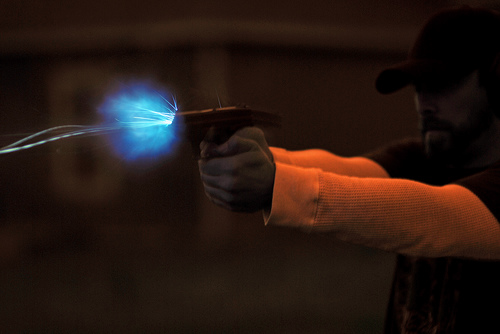

<START> <UNKNOWN> man in a dark hat shoots a wood . <END>


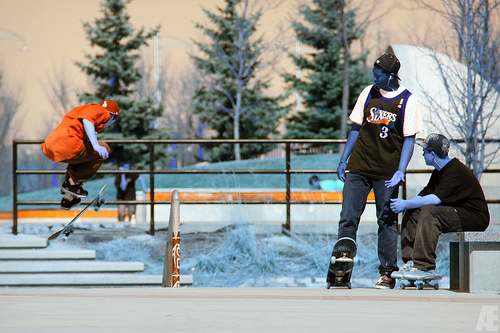

<START> <UNKNOWN> boy in blue jumps on a skateboard while two others watch him <END>


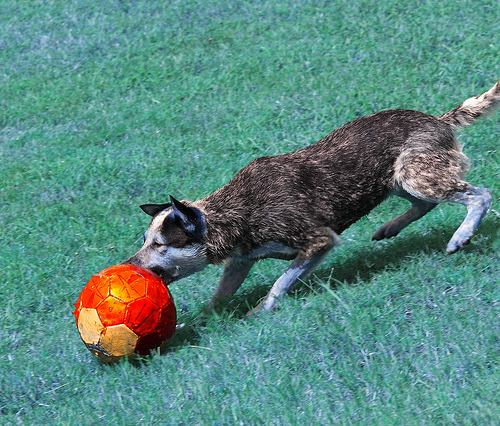

<START> a dog playing with a blue ball <END>


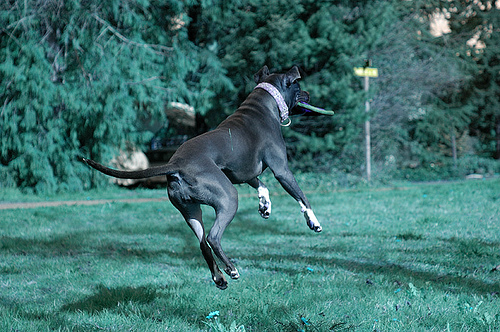

<START> <UNKNOWN> dog with collar jumping up with a stick in his mouth <END>


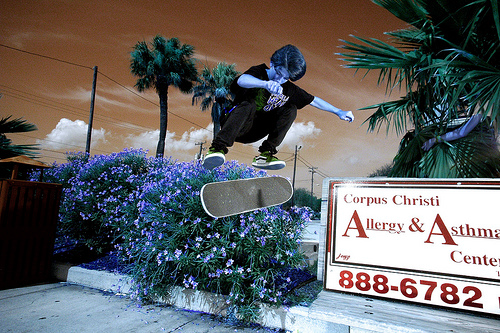

<START> <UNKNOWN> jumping skateboard beside sign and pink flowers <END>


In [27]:
iterations = 0
max_iterations = 5

# Reverse the vocabulary_mapping for decoding
id_to_word = {idx: word for word, idx in vocabulary_mapping.items()}

for epoch in range(1):
  for images, captions in training_data:
    images, captions = images.to(device), captions.to(device)
    prediction = model(images, captions) # B, T, V
    _, indices = torch.max(prediction, dim=-1)
    first_caption = indices[0]
    sentence = []
    for id in first_caption:
      word = id_to_word.get(id.item(), '<UNKNOWN>')  # Convert tensor to int and use get() with a default value
      sentence.append(word)
      if id.item() == vocabulary_mapping['<END>']:  # Use the actual end token index
        break
    print(' '.join(sentence))
    B, T, vocab_size = prediction.shape
    prediction = prediction.view(B*T, vocab_size)
    loss = loss_fn(prediction, captions.view(B*T))
    optimizer.zero_grad()
    loss.backward()
    nn.utils.clip_grad_norm_(model.parameters(), 2.0)  # Use clip_grad_norm_ with underscore
    optimizer.step()
    iterations+=1
    if iterations == max_iterations:
      break